# Example: Kernel-based Dynamics - Lorenz-63

- Author: Dr. Daning Huang
- Date: 12/12/2025
- Updated: 05/07/2026

## Introduction

In the previous kernel example, we introduced the configuration of kernel models and the training procedure. Due to its linearity, kernel methods are one of the simplest model families for handling nonlinearity. A subtle but important step is choosing hyperparameters such as the kernel lengthscale and the ridge parameter. In our [prior work](https://arxiv.org/abs/2512.17203), we show that careful hyperparameter selection is critical for accuracy, and with a good choice kernel models can compete with more sophisticated neural-network baselines.

In this example, we revisit the classical Lorenz-63 system using the current DyMAD training/config workflow. We will generate reproducible data, run kernel CV sweeps with the current `LinearTrainer` interface, and then extend the sweep with `continue_training=True`.

## Problem Setup

The usual imports:

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import copy
import matplotlib.pyplot as plt
import numpy as np
import torch

from dymad.io import load_model
from dymad.losses import vpt_loss
from dymad.models import DKMSK
from dymad.training import LinearTrainer
from dymad.utils import TrajectorySampler, plot_cv_results, plot_multi_trajs, plot_trajectory

We generate the data in a specific way. To obtain a trajectory of length $N$, we start from a random initial condition, integrate for $N+4000$ steps with a step size of $0.01$, and discard the first $4000$ steps. This keeps the retained trajectory on the Lorenz attractor.

We generate one long trajectory for training and validation, then 50 fresh trajectories for testing. To keep reruns reproducible, we also fix the random seed and create the local `data/` directory before writing artifacts.

In [2]:
SEED = 12345
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

M = 2048  # Training
V = 2000  # Validation
t_grid = np.linspace(0, 120, 12000)  # Train+valid, with extra 4000 for burn-in
t_pred = np.linspace(0, 60, 6000)    # Test, with extra 4000 for burn-in

sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0
def f(t, x):
    dxdt = np.zeros_like(x)
    dxdt[0] = sigma * (x[1] - x[0])
    dxdt[1] = x[0] * (rho - x[2]) - x[1]
    dxdt[2] = x[0] * x[1] - beta * x[2]
    return dxdt

In [3]:
"""lor_data.yaml
dims:
  states: 3
  inputs: 0
  observations: 3

x0:
  kind: uniform
  params:
    bounds:
      - [-1.0, 1.0]
      - [-1.0, 1.0]
      - [-1.0, 1.0]

solver:
  method: RK45
  rtol: 1.0e-8
  atol: 1.0e-8

postprocess:
  n_skip: 4000    # Extra option to discard initial steps
  shift_t: true   # Reset initial time to 0 after discarding
"""

'lor_data.yaml\ndims:\n  states: 3\n  inputs: 0\n  observations: 3\n\nx0:\n  kind: uniform\n  params:\n    bounds:\n      - [-1.0, 1.0]\n      - [-1.0, 1.0]\n      - [-1.0, 1.0]\n\nsolver:\n  method: RK45\n  rtol: 1.0e-8\n  atol: 1.0e-8\n\npostprocess:\n  n_skip: 4000    # Extra option to discard initial steps\n  shift_t: true   # Reset initial time to 0 after discarding\n'

In [4]:
# Data generation
sampler = TrajectorySampler(f, config='lor_data.yaml', rng=SEED)
ts, xs, ys = sampler.sample(t_grid, batch=1)

np.savez_compressed(DATA_DIR / 'l63_train.npz', t=ts[0][:M], x=xs[0][:M])
np.savez_compressed(
    DATA_DIR / 'l63_valid.npz',
    t=ts[0][:V],
    x=np.array([xs[0][M:M+V], xs[0][M+V:M+2*V]]),
)

tt, xt, yt = sampler.sample(t_pred, batch=50)
np.savez_compressed(DATA_DIR / 'l63_test.npz', t=tt, x=xt)

The training data is illustrated below, sketching the well-known Lorenz butterfly.

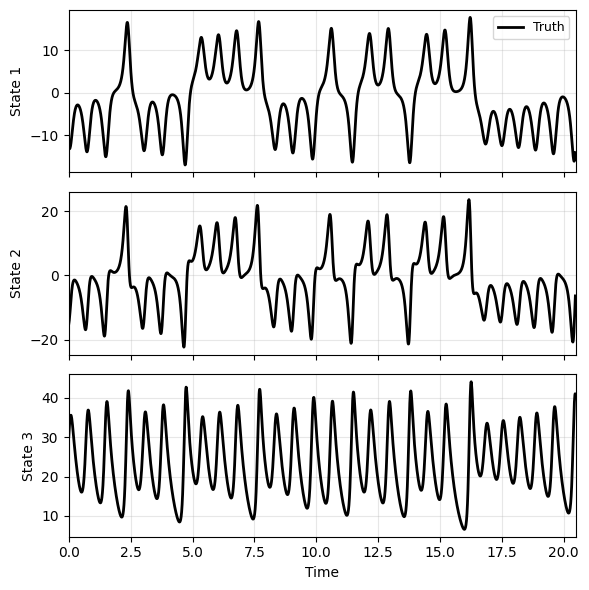

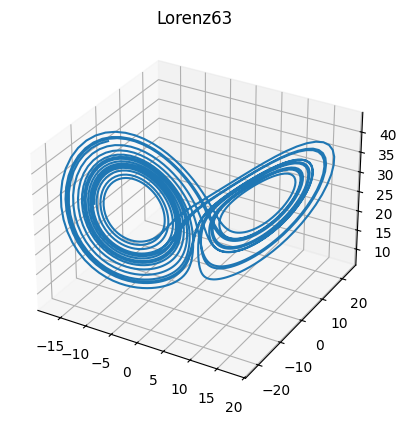

In [5]:
plot_trajectory(np.array(xs[0][:M]), ts[0][:M], None, labels=['Truth'], ifclose=False)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs[0, :M, 0], xs[0, :M, 1], xs[0, :M, 2])
ax.set_title("Lorenz63");

## Configuring the Models

Next we set up the kernel models. Here we compare the standard Gaussian radial basis function (RBF) kernel against the diffusion-map (DM) kernel used in the maintained Lorenz-63 training script.

In [6]:
RIDGE = 1e-6
DIM = 3  # State dimension

# Configuration of kernels
opt_rbf = {
    'type': 'sc_rbf',
    'input_dim': DIM,
    'lengthscale_init': None,
}
opt_dm = {
    'type': 'sc_dm',
    'input_dim': DIM,
    'eps_init': None,
}

# Configuration of multi-output shared kernel models
mdl_rbf = {
    'name': 'ker_model',
    'encoder_layers': 0,
    'decoder_layers': 0,
    'kernel_dimension': DIM,
    'type': 'share',
    'kernel': opt_rbf,
    'dtype': torch.float64,
    'ridge_init': RIDGE,
    'jitter': 0.0,
}
mdl_dm = copy.deepcopy(mdl_rbf)
mdl_dm['kernel'] = opt_dm

Next, we choose the standard linear trainer.

In [7]:
trn_ln = {
    'n_epochs': 1,
    'method': 'raw',
}

The main new ingredient is the CV sweep. For Lorenz-63 we use `metric: "vpt"`, which refers to the validation VPT loss used during model selection. That loss is minimized during CV even though larger raw VPT values are better when we inspect final predictions.

The current maintained Lorenz-63 setup uses a focused one-dimensional sweep for each kernel family, then extends the sweep with `continue_training=True`.

In [19]:
cv_rbf = {
    'param_grid': {
        'model.kernel.lengthscale_init': ('linspace', (4.0, 4.2, 15)),
        'model.ridge_init': [1e-13],
    },
    'metric': 'vpt',
}
cv_dm = {
    'param_grid': {
        'model.kernel.eps_init': ('linspace', (1.0, 2.0, 10)),
        'model.ridge_init': [1e-13],
    },
    'metric': 'vpt',
}

Paired with the above configuration is the model file. Here we keep the shared dataset and criterion settings in `lor_model.yaml`, while injecting the model-specific kernel and CV choices through `config_mod`. The separate `data_valid` entry is still the right way to supply a dedicated validation set.

In [9]:
"""lor_model.yaml
data:
  path: './data/l63_train.npz'
  n_samples: 1
  n_steps: 2048
  double_precision: true

data_valid:
  path: './data/l63_valid.npz'
  n_samples: 2
  n_steps: 2000
  double_precision: true

transform_x:
  type: "scaler"
  mode: "std"

split:
  train_frac: 1.0

dataloader:
  batch_size: 1

criterion:
  vpt:
    type: "vpt"
    params:
      gamma: 0.3
"""
config_path = 'lor_model.yaml'

Collect the configurations:

In [20]:
cfgs = [
    ('dks_rbf', DKMSK, LinearTrainer, {'model': mdl_rbf, 'cv': cv_rbf, 'training': trn_ln}),
    ('ddm_dm', DKMSK, LinearTrainer, {'model': mdl_dm, 'cv': cv_dm, 'training': trn_ln}),
]

IDX = [0, 1]
labels = [cfgs[i][0] for i in IDX]

## Training and Validation
### Round 1

Train the initial CV sweeps. DyMAD will evaluate each parameter combination, write the trial artifacts under the run directory, and save an aggregated `*_cv.npz` file for later inspection.

In [21]:
for i in IDX:
    mdl, MDL, Trainer, opt = cfgs[i]
    opt["model"]["name"] = f"lor_{mdl}"
    trainer = Trainer(config_path, MDL, config_mod=opt)
    trainer.train()

After the first round, inspect the validation VPT-loss sweep for each model. Lower values are better here because the CV metric is the VPT loss, not the raw VPT measured in prediction steps.

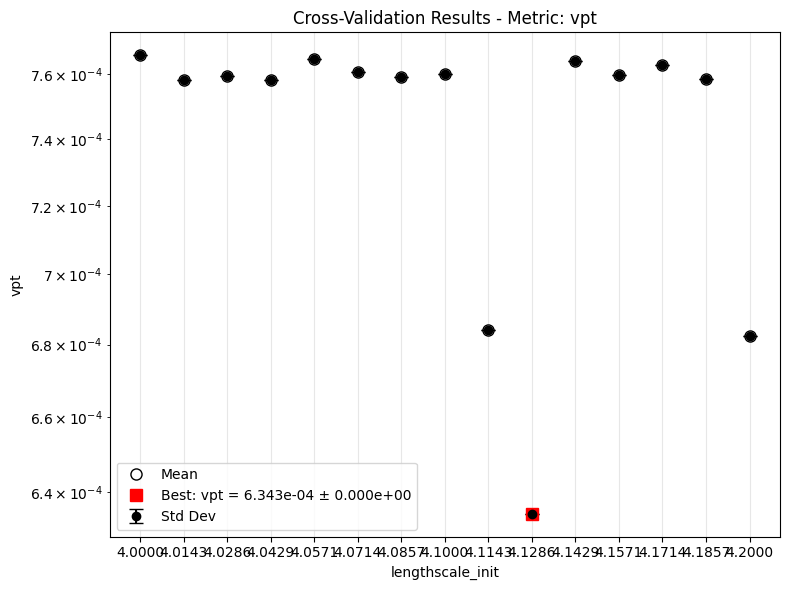

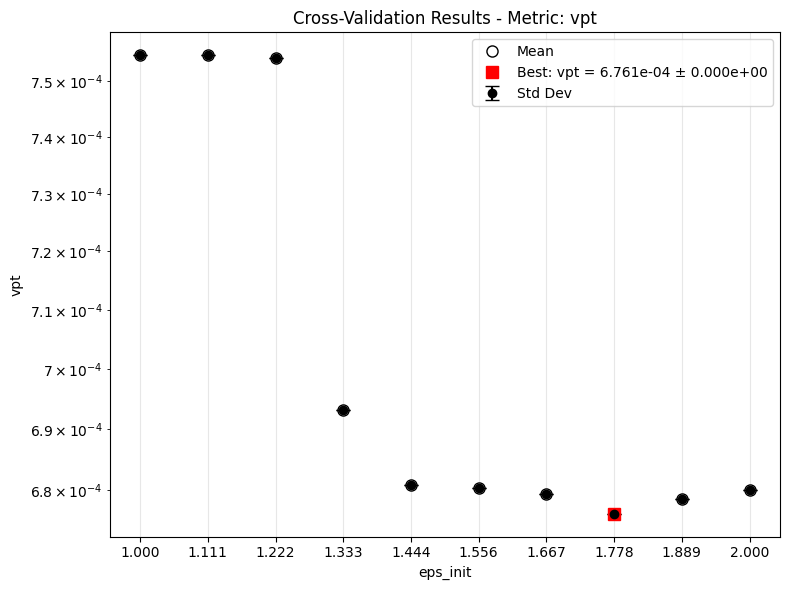

In [22]:
for i in IDX:
    mdl = cfgs[i][0]
    if i == 0:
        _key = 'model.kernel.lengthscale_init'
    else:
        _key = 'model.kernel.eps_init'
    _, ax = plot_cv_results(f'lor_{mdl}', [_key], ifclose=False)
    ax.set_yscale('log')

### Round 2

If you want to extend the search, update the CV range and resume from the existing run directory. With `continue_training=True`, DyMAD appends the new trials to the previous CV results instead of starting over.

In [23]:
cv_rbf = {
    'param_grid': {
        'model.kernel.lengthscale_init': ('linspace', (4.1, 4.15, 10)),
        'model.ridge_init': [1e-13],
    },
    'metric': 'vpt',
}
cv_dm = {
    'param_grid': {
        'model.kernel.eps_init': ('linspace', (1.6, 1.9, 10)),
        'model.ridge_init': [1e-13],
    },
    'metric': 'vpt',
}
cfgs = [
    ('dks_rbf', DKMSK, LinearTrainer, {'model': mdl_rbf, 'cv': cv_rbf, 'training': trn_ln}),
    ('ddm_dm', DKMSK, LinearTrainer, {'model': mdl_dm, 'cv': cv_dm, 'training': trn_ln}),
]

In [24]:
for i in IDX:
    mdl, MDL, Trainer, opt = cfgs[i]
    opt["model"]["name"] = f"lor_{mdl}"
    trainer = Trainer(config_path, MDL, config_mod=opt)
    trainer.train(continue_training=True)  # Option to recycle previous results

Plot the accumulated CV results again after the resumed sweep.

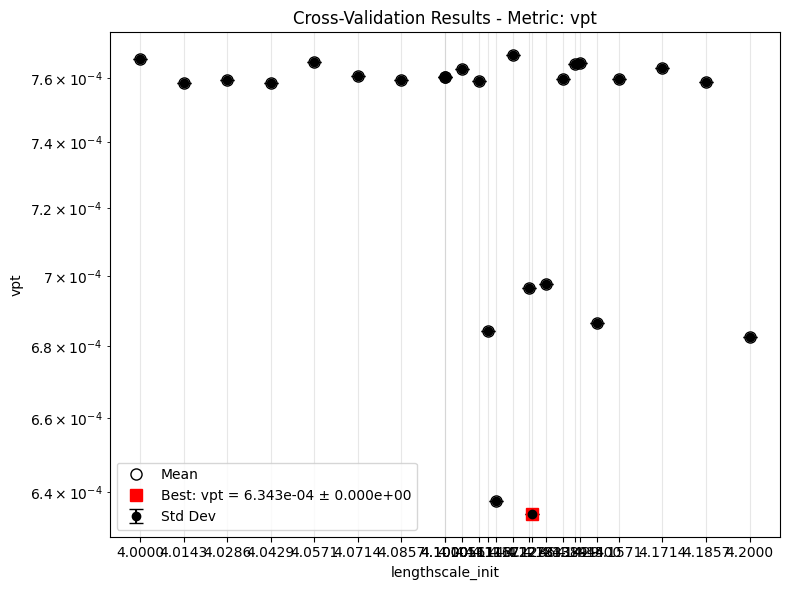

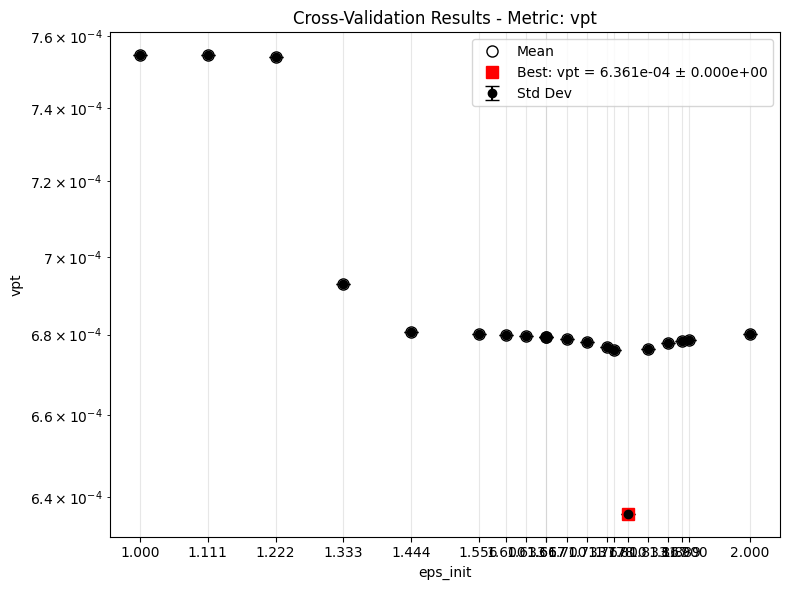

In [25]:
for i in IDX:
    mdl = cfgs[i][0]
    if i == 0:
        _key = 'model.kernel.lengthscale_init'
    else:
        _key = 'model.kernel.eps_init'
    _, ax = plot_cv_results(f'lor_{mdl}', [_key], ifclose=False)
    ax.set_yscale('log')

## Results

Lastly we make predictions on the held-out test trajectories and plot two of them. We then summarize the VPT distribution computed from the exact `vpt_loss` helper.

In [26]:
data = np.load(DATA_DIR / 'l63_test.npz')
ts = torch.tensor(data['t'], dtype=torch.float64)
xs = torch.tensor(data['x'], dtype=torch.float64)
JDX = 20

res = [xs[:JDX]]
for _i in IDX:
    mdl, MDL, _, _ = cfgs[_i]
    _, prd_func = load_model(MDL, f'lor_{mdl}.pt')
    with torch.no_grad():
        pred = prd_func(xs[:JDX], ts[:JDX])
    res.append(pred)

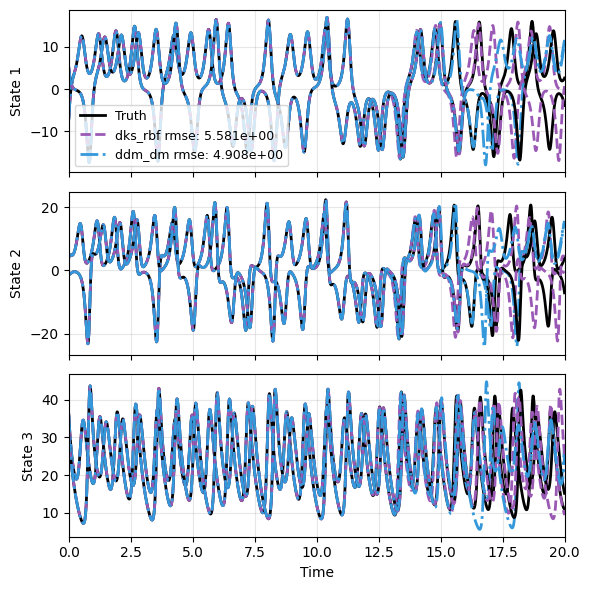

In [27]:
plot_multi_trajs(
    np.array([r[:2] for r in res]), ts[0], "L63",
    labels=['Truth']+labels, ifclose=False)

For a better characterization of the final prediction quality, we can use a violin plot of the exact VPT values. Below `vpt_loss` is a convenient helper for computing those step counts on the held-out trajectories.

In this setup the DM kernel typically outperforms the plain RBF kernel, in the sense of better mean and smaller variance; the plausible explanation is the consistency of DM with the geometry of the Lorenz attractor.

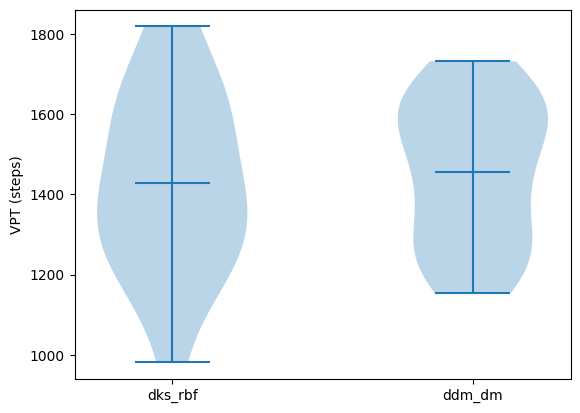

In [28]:
vpt_rb, avr_rb = vpt_loss(res[1], res[0], gamma=0.3)
vpt_dm, avr_dm = vpt_loss(res[2], res[0], gamma=0.3)

f = plt.figure()
plt.violinplot([vpt_rb, vpt_dm], showmeans=True)
plt.xticks([1, 2], labels)
plt.ylabel("VPT (steps)");

We also provide more validation algorithms other than grid search.  See `scripts/linear_time_invariant/lti_nm.py` for an example of using a Nelder-Mead-like optimizer to search for the optimal hyperparameters.  There is also a parallelized multi-start Nelder-Mead optimizer.